1. Importar Librerías Necesarias

In [32]:

# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Cargar los Datos

In [33]:
# Cargamos los datos desde los archivos CSV
data1 = pd.read_csv('../data/raw/airline_satisfaction_part1.csv')
data2 = pd.read_csv('../data/raw/airline_satisfaction_part2.csv')

# Combinamos los dos DataFrames en uno solo
data = pd.concat([data1, data2], ignore_index=True)

3. Eliminar Columnas Irrelevantes

In [34]:
# Eliminar columna "Unnamed: 0"
data.drop(columns=['Unnamed: 0'], inplace=True)

In [35]:
# Confirmamos la eliminación de la columna "Unnamed: 0"
data.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,...,2,2,2,2,4,2,4,0,20.0,satisfied


4. Manejo de Datos Faltantes

In [36]:
# Rellenamos los valores faltantes en una columna específica con la mediana de la columna
data['Arrival Delay in Minutes'].fillna(data['Arrival Delay in Minutes'].median(), inplace=True)

In [37]:
# Confirmamos la falta de valores nulos en los datos
data.isnull().sum()

id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

5. Conversión de Tipos de Datos

In [38]:
# Convertir "Arrival Delay in Minutes" de float a int después de imputar valores nulos
data['Arrival Delay in Minutes'] = data['Arrival Delay in Minutes'].astype('int')

In [39]:
# Confirmamos el cambio de tipo de datos
data.dtypes

id                                    int64
Gender                               object
Customer Type                        object
Age                                   int64
Type of Travel                       object
Class                                object
Flight Distance                       int64
Inflight wifi service                 int64
Departure/Arrival time convenient     int64
Ease of Online booking                int64
Gate location                         int64
Food and drink                        int64
Online boarding                       int64
Seat comfort                          int64
Inflight entertainment                int64
On-board service                      int64
Leg room service                      int64
Baggage handling                      int64
Checkin service                       int64
Inflight service                      int64
Cleanliness                           int64
Departure Delay in Minutes            int64
Arrival Delay in Minutes        

6. Detección y Eliminación de Duplicados

In [40]:
# Contamos la cantidad de filas duplicadas
data.duplicated().sum()

0

In [ ]:
# En dado caso que existan filas duplicadas podemos utilizar el siguiente codigo para eliminarlas, el codigo estara comentado
#df.drop_duplicates(inplace=True)

Apesar de no contar con filas duplicados en la etapa de exploración, siempre es buena practica estar seguros.

6. Corregir Tipos de Datos

In [43]:
# Convertimos columnas a los tipos de datos correctos
data["Arrival Delay in Minutes"] = data["Arrival Delay in Minutes"].astype("int")

In [42]:
# Confirmamos el cambio de tipo de dato en la columna "Arrival Delay in Minutes"
data.dtypes

id                                    int64
Gender                               object
Customer Type                        object
Age                                   int64
Type of Travel                       object
Class                                object
Flight Distance                       int64
Inflight wifi service                 int64
Departure/Arrival time convenient     int64
Ease of Online booking                int64
Gate location                         int64
Food and drink                        int64
Online boarding                       int64
Seat comfort                          int64
Inflight entertainment                int64
On-board service                      int64
Leg room service                      int64
Baggage handling                      int64
Checkin service                       int64
Inflight service                      int64
Cleanliness                           int64
Departure Delay in Minutes            int64
Arrival Delay in Minutes        

7. Visualización de Valores Atípicos

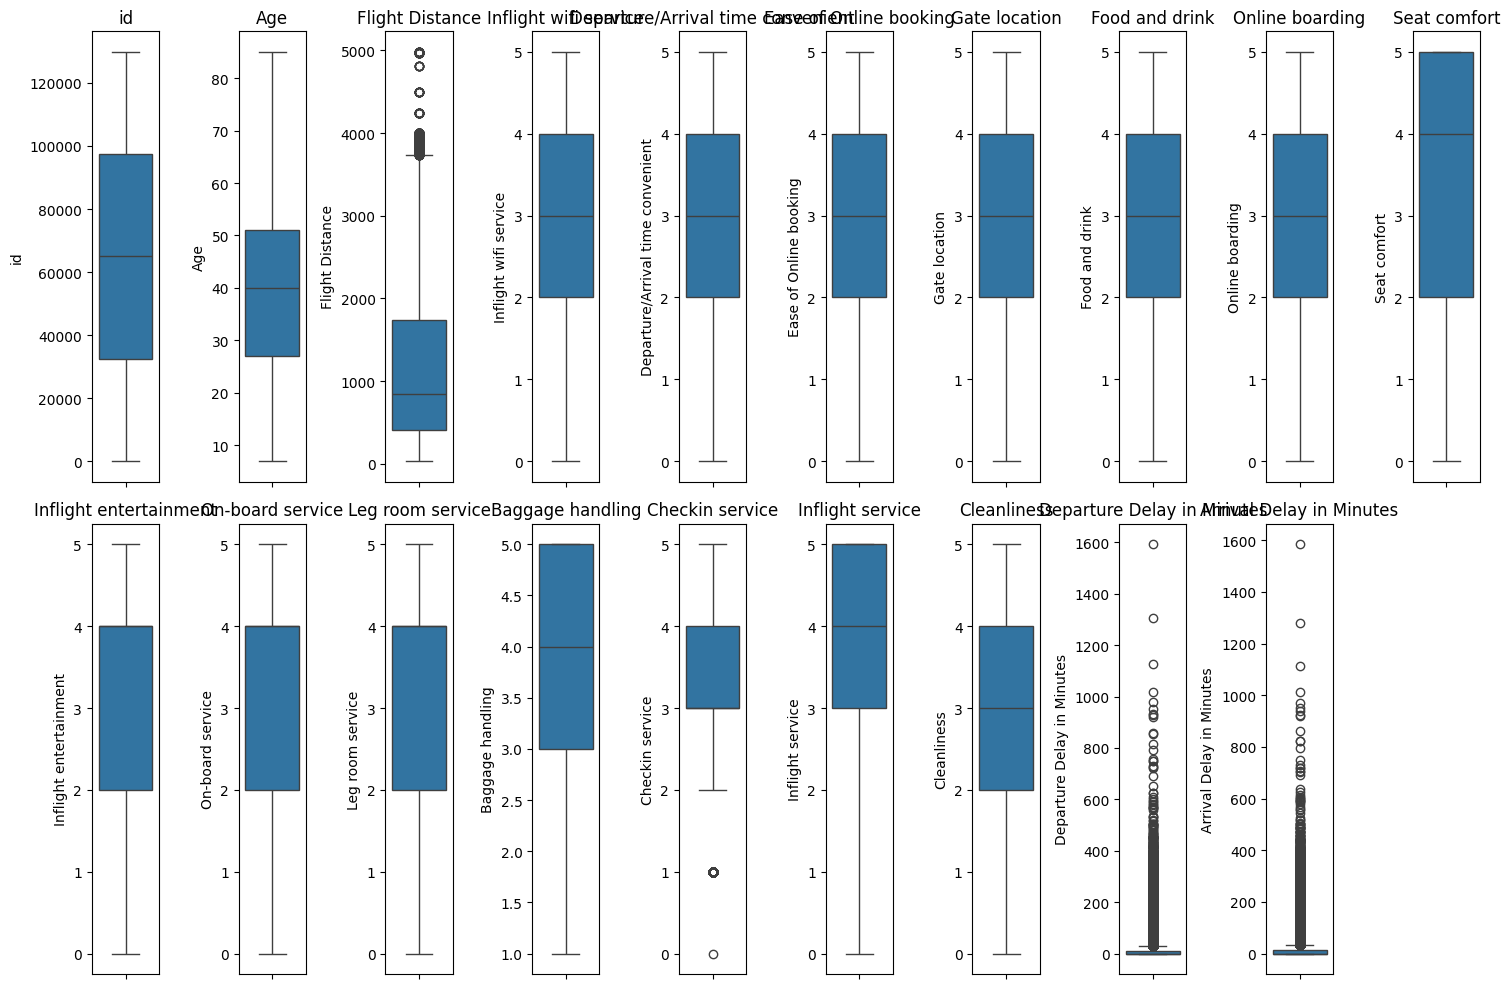

In [54]:
# Seleccionamos las columnas numéricas para visualización
num_columns = data.select_dtypes(include=[np.number]).columns

# Creamos subplots de boxplots para cada columna numérica
plt.figure(figsize=(15, 10))  # Ajustamos el tamaño de la figura

# Crear un boxplot para cada columna numérica
for i, column in enumerate(num_columns, 1):
    plt.subplot(2, (len(num_columns) + 1) // 2, i) # Ajustamos la cuadrícula para tener suficiente espacio
    sns.boxplot(y=data[column])
    plt.title(column)

plt.tight_layout() # Ajustamos el layout para evitar superposiciones
plt.show()


<Axes: >

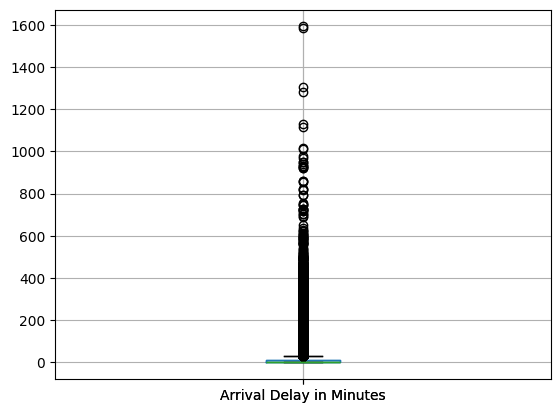

In [56]:
# Destacamos valores atípicos en la columna "Departure Delay in Minutes"
data.boxplot(["Departure Delay in Minutes"])

<Axes: >

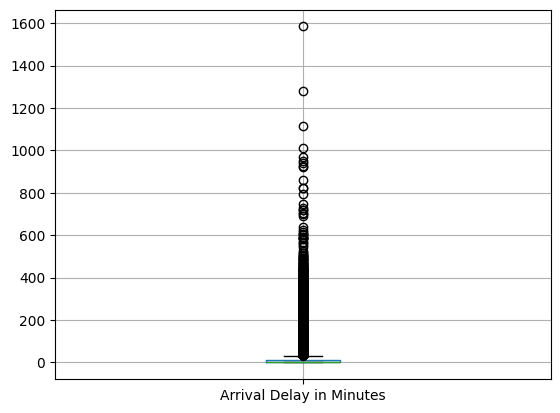

In [57]:
# Destacamos valores atípicos en la columna "Departure Delay in Minutes"
data.boxplot(["Arrival Delay in Minutes"])

In [46]:
# Función para eliminar valores atípicos usando el método IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

Tratamiento de Valores Atípicos en la Columna "Arrival Dealy in Minutes"

In [58]:
# Eliminamos de valores atípicos
data = remove_outliers(data, "Arrival Delay in Minutes")

<Axes: >

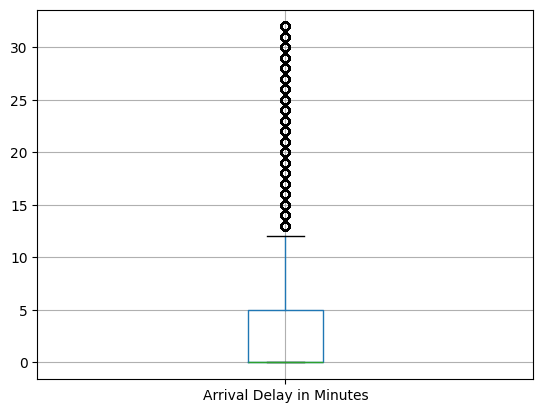

In [59]:
# Confirmamos visualmente la eliminación de valores atípicos en la columna "Arrival Delay in Minutes"
data.boxplot(["Arrival Delay in Minutes"])

Tratamiento de Valores Atípicos en la Columna "Departure Dealy in Minutes"

In [60]:
# Eliminamos los valores atípicos en la columna "Departure Delay in Minutes"
data = remove_outliers(data, "Departure Delay in Minutes")

<Axes: >

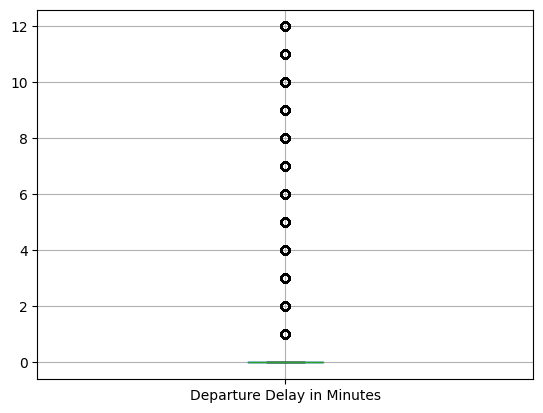

In [61]:
# Confirmamos visualmente la eliminación de valores atípicos en la columna "Departure Delay in Minutes"
data.boxplot(["Departure Delay in Minutes"])

9. Guardar el Dataset Limpio

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96500 entries, 1 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   id                                 96500 non-null  int64 
 1   Gender                             96500 non-null  object
 2   Customer Type                      96500 non-null  object
 3   Age                                96500 non-null  int64 
 4   Type of Travel                     96500 non-null  object
 5   Class                              96500 non-null  object
 6   Flight Distance                    96500 non-null  int64 
 7   Inflight wifi service              96500 non-null  int64 
 8   Departure/Arrival time convenient  96500 non-null  int64 
 9   Ease of Online booking             96500 non-null  int64 
 10  Gate location                      96500 non-null  int64 
 11  Food and drink                     96500 non-null  int64 
 12  Online b

In [63]:
# Guardamos el DataFrame limpio en un archivo CSV en la carpeta 'processed'
data.to_csv("../data/processed/airline_satisfaction_cleaned.csv", index=False)
print("Dataset limpio guardado en '../data/processed/airline_satisfaction_cleaned.csv'")

Dataset limpio guardado en '../data/processed/airline_satisfaction_cleaned.csv'
